In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import GridSearchCV
from sklearn.datasets import fetch_california_housing, load_iris
from sklearn import tree

ModuleNotFoundError: No module named 'matplotlib.backends.registry'

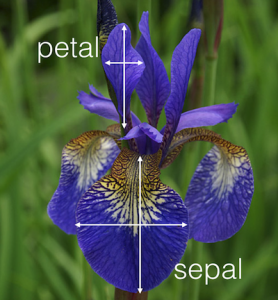

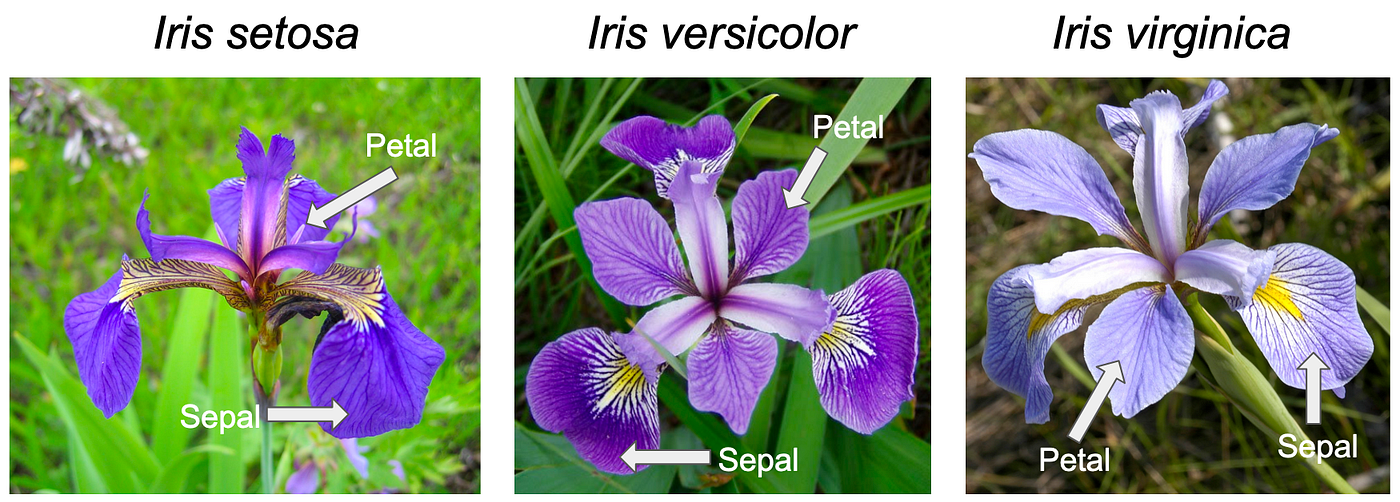

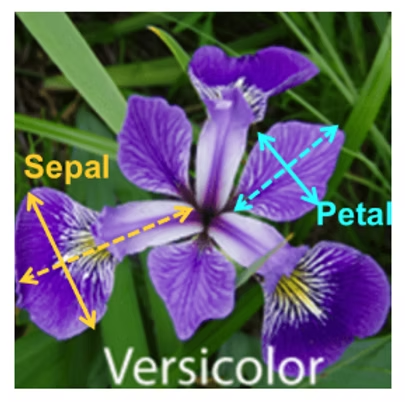

In [ ]:
df = load_iris(as_frame=True).frame
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


0 = Iris-Setosa

1 = Iris-Versicolor

2 = Iris-Virginica

In [ ]:
X = df.drop(columns=['target'])
y = df['target']

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [ ]:
default_pipeline = Pipeline(steps=[
    ('dtmodel',DecisionTreeClassifier(random_state=42))
])

default_pipeline.fit(X_train,y_train)

,steps,"[('dtmodel', ...)]"
,transform_input,None
,memory,None
,verbose,False
,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None


In [ ]:
dtm = DecisionTreeClassifier(random_state=42)

In [ ]:
dtm

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [ ]:
dtm.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [ ]:
dtm.feature_importances_

array([0.00625   , 0.02916667, 0.5585683 , 0.40601504])

In [ ]:
dtm.tree_

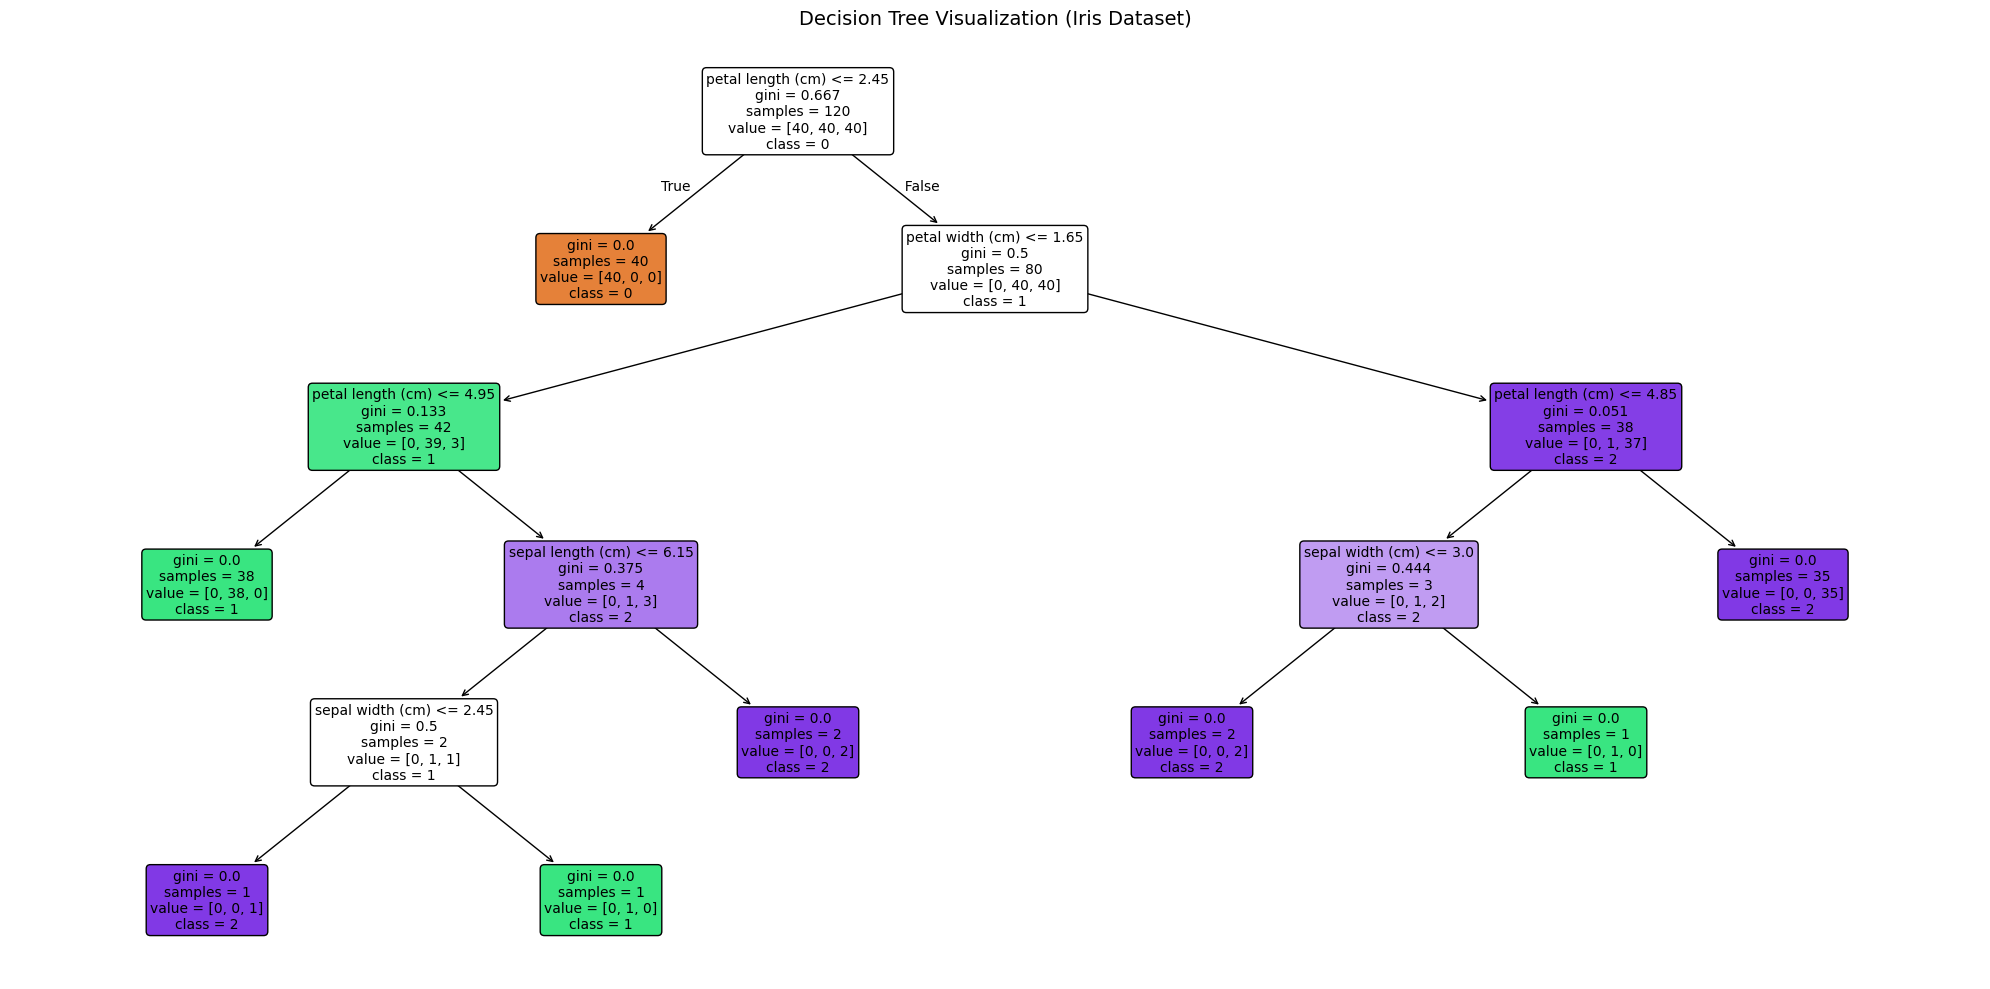

In [ ]:
fig, ax = plt.subplots(figsize=(20, 10))

tree.plot_tree(
    dtm,
    feature_names=list(dtm.feature_names_in_),  # ['sepal length (cm)', 'sepal width (cm)', ...]
    class_names=list(dtm.classes_.astype(str)),  # ['0', '1', '2']
    filled=True,        # node গুলো class অনুযায়ী color হবে
    rounded=True,       # corner rounded দেখাবে
    fontsize=10,
    ax=ax
)

plt.title("Decision Tree Visualization (Iris Dataset)", fontsize=14)
plt.tight_layout()
plt.savefig("dtm_tree.png", dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
dtm.classes_

array([0, 1, 2])

In [ ]:
dtm.n_features_in_

4

In [ ]:
dtm.feature_names_in_

array(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)'], dtype=object)

In [ ]:
dtm.n_classes_

3

In [ ]:
dtm.n_outputs_

1

In [ ]:
y_pred = default_pipeline.predict(X_test)

In [ ]:
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.90      0.90      0.90        10
           2       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



In [ ]:
param_grid = {
    'dtmodel__criterion': ['gini','entropy'],
    'dtmodel__max_depth': [3,4,5,None],
    'dtmodel__min_samples_split': [2,5,10],
    'dtmodel__min_samples_leaf': [1,2,4]
}

grid_search = GridSearchCV(
    estimator=default_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train,y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'dtmodel__criterion': ['gini', 'entropy'], 'dtmodel__max_depth': [3, 4, ...], 'dtmodel__min_samples_leaf': [1, 2, ...], 'dtmodel__min_samples_split': [2, 5, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [ ]:
grid_search.best_params_

{'dtmodel__criterion': 'gini',
 'dtmodel__max_depth': 4,
 'dtmodel__min_samples_leaf': 1,
 'dtmodel__min_samples_split': 2}

In [ ]:
grid_search.best_score_

0.9416666666666668

In [ ]:
best_model_pipe = grid_search.best_estimator_
y_pred = best_model_pipe.predict(X_test)

accuracy_score(y_test,y_pred)

0.9333333333333333